In [7]:
import re
import h5py
import numpy as np
import matplotlib.pyplot as plt

filename = "nn_dineutron_spectrum.h5"
L = 48

In [10]:
def bootstrap_error(samples):
    return np.std(samples[1:], ddof=1)


levels = []

with h5py.File(filename, "r") as f:
    mN = f["mN/E0"][:]
    punit2 = (2.0 * np.pi / L)**2

    for name in sorted(f.keys()):
        if name == "mN":
            continue

        group = f[name]
        match = re.search(r"Psq(\d+)", name)

        if match is None:
            continue

        total_psq = int(match.group(1))
        n1_psq = int(group["Psq_N1"][0])
        n2_psq = int(group["Psq_N2"][0])
        dE = group["dE_NN"][:]

        E1 = np.sqrt(mN**2 + punit2 * n1_psq)
        E2 = np.sqrt(mN**2 + punit2 * n2_psq)

        E_lab = dE + E1 + E2
        E_cm = np.sqrt(E_lab**2 - punit2 * total_psq)

        levels.append({
            "name": name,
            "E_cm": E_cm[0],
            "error": bootstrap_error(E_cm),
        })

print(f"Found {len(levels)} energy levels")
for level in levels:
    print(level["name"], level["E_cm"], level["error"])

0
1
1
0
1
0
0
1
Found 8 energy levels
A1_Psq1_level0 1.4097814949159677 0.0007684675439241838
A1_Psq1_level1 1.4333221966427518 0.0008761569775460531
A1_Psq2_level0 1.4147421255240087 0.0008041403937385471
A1_Psq3_level0 1.4199751076807943 0.0008105941934642061
A1_Psq4_level0 1.4044221450218684 0.0007675244981894147
A1_Psq4_level1 1.4271811314910883 0.00084483133111793
A1g_Psq0_level0 1.404480193149725 0.0007506551218981072
A1g_Psq0_level1 1.427387430256371 0.0007935596115245533


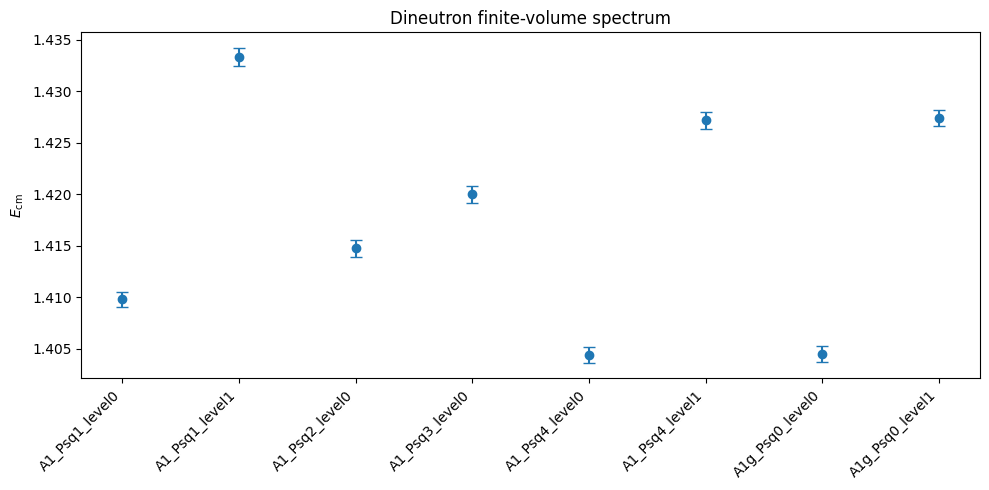

In [9]:
labels = [level["name"] for level in levels]
energies = np.array([level["E_cm"] for level in levels])
errors = np.array([level["error"] for level in levels])

x = np.arange(len(levels))

plt.figure(figsize=(10, 5))
plt.errorbar(x, energies, yerr=errors, fmt="o", capsize=4)

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel(r"$E_{\rm cm}$")
plt.title("Dineutron finite-volume spectrum")
plt.tight_layout()
plt.show()